<a href="https://colab.research.google.com/github/mudather490/Nurons_network-projects/blob/main/Unmpy_Nurons_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Make Nurons network By Numpy**

### Step 1: Initialize Parameters

In [57]:
import numpy as np

class NeuralNetwork:
    def __init__(self, input_size=2, hidden_size=3, output_size=1):
        # Step 1: Initialize Parameters
        self.w1 = np.random.randn(hidden_size, input_size)
        self.b1 = np.zeros((hidden_size, 1))
        self.w2 = np.random.randn(output_size, hidden_size)
        self.b2 = np.zeros((output_size, 1))

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def relu(self, z):
        return np.maximum(0, z)

    def relu_derivative(self, z):
        return z > 0

    def mse_loss(self, y_pred, y_true):
        return np.mean(np.square(y_pred - y_true))

    def forward(self, x):
        self.z1 = np.dot(self.w1, x) + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = np.dot(self.w2, self.a1) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def backward(self, X, y):
        m = X.shape[1]
        dz2 = self.a2 - y
        dw2 = (1/m) * np.dot(dz2, self.a1.T)
        db2 = (1/m) * np.sum(dz2, axis=1, keepdims=True)
        da1 = np.dot(self.w2.T, dz2)
        dz1 = da1 * (self.a1 * (1 - self.a1))
        dw1 = (1/m) * np.dot(dz1, X.T)
        db1 = (1/m) * np.sum(dz1, axis=1, keepdims=True)
        return dw1, db1, dw2, db2

    def train(self, X, Y, iterations, alpha):
        for i in range(iterations):
            self.forward(X)
            dw1, db1, dw2, db2 = self.backward(X, Y)
            self.w1 -= alpha * dw1
            self.b1 -= alpha * db1
            self.w2 -= alpha * dw2
            self.b2 -= alpha * db2
            if i % 1000 == 0:
                loss = self.mse_loss(self.a2, Y)
                print(f"Iteration {i}, Loss: {loss:.6f}")

    def predict(self, X):
        a2 = self.forward(X)
        return np.round(a2)

    def evaluate(self, X, Y):
        predictions = self.predict(X)
        # True Positives, False Positives, False Negatives
        tp = np.sum((predictions == 1) & (Y == 1))
        fp = np.sum((predictions == 1) & (Y == 0))
        fn = np.sum((predictions == 0) & (Y == 1))
        tn = np.sum((predictions == 0) & (Y == 0))

        accuracy = (tp + tn) / Y.size
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0

        return {
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall
        }

### Step 2: Forward Propagation

we make  layers using the formula $Z = WX + b$ and an activation function like Sigmoid.

In [58]:
#forward propagation
def sigmoid(z) :
  return 1/(1+ np.exp(-z))

def forword_prop(w1, b1, w2, b2, x):
  z1 = np.dot(w1, x)+ b1
  a1 = sigmoid(z1)
  z2 = np.dot(w2, a1)+ b2
  a2 = sigmoid(z2)

  return z1, a1, z2, a2




### Step 3: Backward Propagation

---


We calculate the gradient of the loss with respect to each parameter to update them.

In [59]:
# backward propagation
def backword_prop(w1, b1, w2, b2, z1, a1, z2, a2, X, y):
  m = X.shape[1]

  # Output layer gradients
  dz2= a2-y
  dw2= (1/m)*np.dot(dz2, a1.T)
  db2= (1/m)*np.sum(dz2, axis=1, keepdims=True)


  #Hidden Layer gradients
  da1 = np.dot(w2.T, dz2)
  dz1 = da1 * (a1 *(1 - a1))
  dw1 = (1/m)*np.dot(dz1, X.T)
  db1 = (1/m)*np.sum(dz1, axis=1, keepdims=True)

  return dw1, db1, dw2, db2

In [60]:
def update_parms(w1, b1, w2, b2, dw1, db1, dw2, db2, alpha):
  w1 = w1- alpha * dw1
  b1 = b1- alpha * db1
  w2 = w2 - alpha * dw2
  b2 = b2 - alpha * db2

  return w1, b1, w2, b2

### Step 5: Putting it all together (The XOR Project)


In [61]:
# XOR Data
X = np.array([[0, 0, 1, 1], [0, 1, 0, 1]])
Y = np.array([[0, 1, 1, 0]])

# Using the class
model = NeuralNetwork(input_size=2, hidden_size=3, output_size=1)
model.train(X, Y, iterations=10000, alpha=0.5)

Iteration 0, Loss: 0.256133
Iteration 1000, Loss: 0.004065
Iteration 2000, Loss: 0.000223
Iteration 3000, Loss: 0.000067
Iteration 4000, Loss: 0.000031
Iteration 5000, Loss: 0.000018
Iteration 6000, Loss: 0.000012
Iteration 7000, Loss: 0.000008
Iteration 8000, Loss: 0.000006
Iteration 9000, Loss: 0.000005


### Step 6: Testing the Model

In [62]:
# Final predictions using the class instance
predictions = model.predict(X)
metrics = model.evaluate(X, Y)

print("Inputs:")
print(X)
print("\nPredicted Outputs (rounded):")
print(predictions)
print("\nPerformance Metrics:")
for metric, value in metrics.items():
    print(f"{metric.capitalize()}: {value:.2f}")

Inputs:
[[0 0 1 1]
 [0 1 0 1]]

Predicted Outputs (rounded):
[[0. 1. 1. 0.]]

Performance Metrics:
Accuracy: 1.00
Precision: 1.00
Recall: 1.00


In [67]:
from sklearn.datasets import load_iris

# 1. Load data
data = load_iris()
X = data.data.T  # Transpose to shape (4, 150) to match (features, samples)
y = data.target.reshape(1, -1)  # Shape (1, 150)

# 2. Re-initialize model for Iris (4 inputs, 3 hidden, 1 output for binary version)
# Note: Iris typically has 3 classes; for this simple NN, let's just train on 4 features.
model = NeuralNetwork(input_size=4, hidden_size=5, output_size=1)

# 3. Train
model.train(X, y, iterations=5000, alpha=0.01)

Iteration 0, Loss: 0.975025
Iteration 1000, Loss: 0.589948
Iteration 2000, Loss: 0.531773
Iteration 3000, Loss: 0.445699
Iteration 4000, Loss: 0.423236


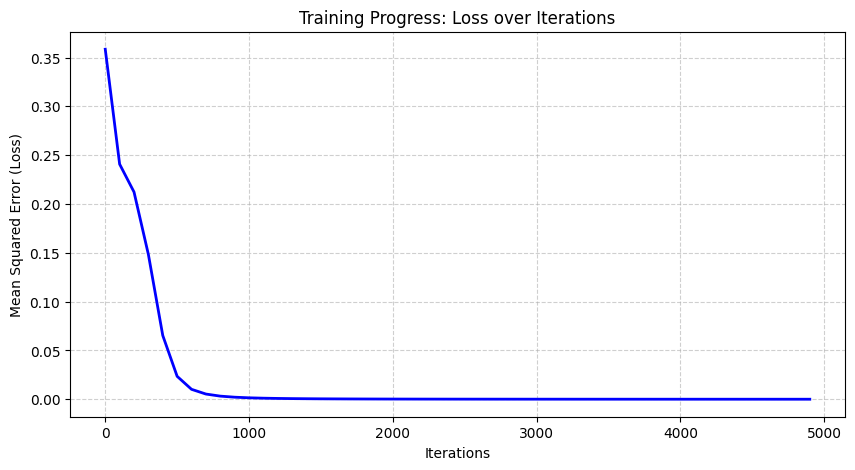

In [68]:
import matplotlib.pyplot as plt

# Let's re-run a training session to capture the loss history for visualization
model_viz = NeuralNetwork(input_size=2, hidden_size=4, output_size=1)
X_xor = np.array([[0, 0, 1, 1], [0, 1, 0, 1]])
Y_xor = np.array([[0, 1, 1, 0]])

loss_history = []
iterations = 5000
alpha = 0.5

for i in range(iterations):
    model_viz.forward(X_xor)
    dw1, db1, dw2, db2 = model_viz.backward(X_xor, Y_xor)
    model_viz.w1 -= alpha * dw1
    model_viz.b1 -= alpha * db1
    model_viz.w2 -= alpha * dw2
    model_viz.b2 -= alpha * db2

    if i % 100 == 0:
        loss_history.append(model_viz.mse_loss(model_viz.a2, Y_xor))

# Plotting the visualization
plt.figure(figsize=(10, 5))
plt.plot(range(0, iterations, 100), loss_history, color='blue', linewidth=2)
plt.title('Training Progress: Loss over Iterations')
plt.xlabel('Iterations')
plt.ylabel('Mean Squared Error (Loss)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()